<a href="https://colab.research.google.com/github/mohand22yehia-commits/telecome_egypt_assigment/blob/main/Copy_of_WE_ML_Complaint_Classification_Summarization_Sentiment_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [229]:
categories = ['Billing', 'Network', 'Technical Support', 'Sales/Plans', 'Other']
columns = [
    'TICKET_ID#',
    'SUBSCRIBER_ID#',
    'CHANNEL',
    'TICKET_TEXT',
    'CATEGORY',
    'RATING',
    'CREATED_DATE'
]
print(f"Categories defined: {categories}")
print(f"Dataset columns defined: {columns}")

Categories defined: ['Billing', 'Network', 'Technical Support', 'Sales/Plans', 'Other']
Dataset columns defined: ['TICKET_ID#', 'SUBSCRIBER_ID#', 'CHANNEL', 'TICKET_TEXT', 'CATEGORY', 'RATING', 'CREATED_DATE']


In [230]:
templates = {
    'Billing': [
        "فاتورتي الشهر ده عالية اوي، ليه خصمتوا {amount} جنيه زيادة؟",
        "I was overcharged {amount} for my last bill. Please check.",
        "fatora 3alya awy el shahr da, leh keda??",
        "The payment of {amount} failed but the money was taken from my account.",
        "مش فاهم ليه في {amount} جنيه زيادة على الفاتورة؟"
    ],
    'Network': [
        "الشبكة وحشة جدا في منطقة {location}، مفيش 4G خالص.",
        "No signal at home since this morning. Network is down.",
        "el shabaka wa7sha awy f {location}, msh عارف اتكلم.",
        "Internet is extremely slow today, I can't even open a website.",
        "النت بيفصل كل شوية والسرعة زفت."
    ],
    'Technical Support': [
        "الراوتر مش شغال واللمبة الحمراء منورة.",
        "My router is blinking red and I've tried restarting it many times.",
        "el router msh shaghal, el lamba el 7amra monawara.",
        "I need help configuring my new router settings.",
        "مش عارف ادخل على اعدادات الراوتر، ممكن مساعدة؟"
    ],
    'Sales/Plans': [
        "عايز احول لنظام {plan} الجديد، ايه الشروط؟",
        "I want to upgrade my current plan to {plan}. How much does it cost?",
        "3ayez a7awel le nizam {plan}, help me plz.",
        "Are there any new offers for the {plan} internet package?",
        "ممكن تفاصيل أكتر عن باقات {plan} المتاحة حالياً؟"
    ],
    'others': [
        "الفرع اللي في {location} زحمة جدا والموظفين بطيئين.",
        "The customer service at the store was very rude.",
        "el mozafen f far3 {location} mo3amlethom wa7sha.",
        "How can I talk to a human agent? The automated system is annoying.",
        "مستوى الخدمة في تراجع مستمر."
    ]
}

print("Templates fixed and verified for categories:", list(templates.keys()))

Templates fixed and verified for categories: ['Billing', 'Network', 'Technical Support', 'Sales/Plans', 'others']


In [231]:
import random
import re
locations = ['Maadi', 'Zamalek', 'Nasr City', 'Alexandria', 'Giza', 'Dokki', 'October City']
plans = ['WE Space Basic', 'WE Space Pro', 'Kix 35', 'Indigo 150', 'Super Mega']
def add_noise(text):
    """Injects typos, repeated punctuation, and emojis into the text."""
    if random.random() < 0.3:
        text = text.replace('?', '??').replace('!', '!!!')
    emojis = ['😡', '😠', '👎', '⚠️', '📶', '💸', '🙏']
    if random.random() < 0.2:
        text += " " + random.choice(emojis)
    if len(text) > 10 and random.random() < 0.1:
        idx = random.randint(0, len(text) - 2)
        text = text[:idx] + text[idx+1] + text[idx] + text[idx+2:]
    return text
def generate_ticket_text(category):
    """Picks a template and fills placeholders."""
    template = random.choice(templates[category])
    ticket = template.format(
        amount=random.randint(50, 500),
        location=random.choice(locations),
        plan=random.choice(plans)
    )
    return add_noise(ticket)
print(f"Sample Billing: {generate_ticket_text('Billing')}")
print(f"Sample Network: {generate_ticket_text('Network')}")

Sample Billing: فاتورتي الشهر ده عالية اوي، ليه خصمتوا 449 جنيه زيادة؟
Sample Network: النت بيفصل كل شوية والسرعة زفت. 🙏


In [232]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

num_tickets = 1000
category_probs = [0.35, 0.30, 0.15, 0.10, 0.10]
data = []
start_date = datetime(2023, 10, 1)

for i in range(num_tickets):
    category = np.random.choice(categories, p=category_probs)
    if category == 'Other':
        category_for_template = 'others'
    else:
        category_for_template = category
    ticket_text = generate_ticket_text(category_for_template)
    channel = random.choice(['Call Center', 'App Chat', 'Social Media'])
    created_date = start_date + timedelta(days=random.randint(0, 90))

    if category in ['Network', 'Billing']:
        rating = np.random.choice([1, 2, 3, 4, 5], p=[0.4, 0.3, 0.2, 0.05, 0.05])
    else:
        rating = np.random.choice([1, 2, 3, 4, 5], p=[0.1, 0.2, 0.3, 0.3, 0.1])
    if random.random() < 0.4:
        rating = np.nan
    data.append({
        'TICKET_ID#': f"TK-{10000 + i}",
        'SUBSCRIBER_ID#': f"SUB-{random.randint(100000, 999999)}",
        'CHANNEL': channel,
        'TICKET_TEXT': ticket_text,
        'CATEGORY': str(category),
        'RATING': rating,
        'CREATED_DATE': created_date.strftime('%Y-%m-%d')
    })
df = pd.DataFrame(data)
print(f"Generated {len(df)} records.")
print("Category distribution:\n", df['CATEGORY'].value_counts(normalize=True))
print(f"\nMissing ratings: {df['RATING'].isna().sum()} ({df['RATING'].isna().mean():.1%})")

Generated 1000 records.
Category distribution:
 CATEGORY
Billing              0.379
Network              0.277
Technical Support    0.147
Other                0.103
Sales/Plans          0.094
Name: proportion, dtype: float64

Missing ratings: 391 (39.1%)


In [233]:
df.to_csv('Tickets.csv', index=False)
print("Successfully saved synthetic dataset to 'Tickets.csv'.")
display(df.head())
import os
file_size = os.path.getsize('Tickets.csv') / 1024
print(f"\nFile size: {file_size:.2f} KB")

Successfully saved synthetic dataset to 'Tickets.csv'.


,TICKET_ID#,SUBSCRIBER_ID#,CHANNEL,TICKET_TEXT,CATEGORY,RATING,CREATED_DATE
0,TK-10000,SUB-354125,Social Media,No signal at home since this morning. Network ...,Network,5.0,2023-11-11
1,TK-10001,SUB-980382,Call Center,My router is blinking red and I've tried resta...,Technical Support,3.0,2023-11-29
2,TK-10002,SUB-110308,Social Media,مش فاهم ليه في 179 جنيه زيادة على الفاتورة؟,Billing,NaN,2023-12-10
3,TK-10003,SUB-772180,Social Media,مش فاهم ليه في 82 جنيه زيادة على الفاتورة؟,Billing,NaN,2023-10-29
4,TK-10004,SUB-997329,App Chat,النت بيفصل كل شوية والسرعة زفت.,Network,NaN,2023-11-01



File size: 118.60 KB


---
## Step 2 — Load & Explore the Data

### Objective
Treat your synthetic dataset the way you'd treat any real one — verify it before trusting it.

### Why This Step Matters
Even data you generated yourself can have bugs: a template that never fires, a rating distribution that's accidentally uniform, categories that leak keywords too obviously. Catching that now saves you from building a pipeline on broken assumptions.

### What To Do
- Load `Tickets.csv`; print shape, dtypes, and a few sample rows.
- Check for missing values, especially in `RATING`.
- Compute and visualize `TICKET_TEXT` length (word count and character count) — histogram.
- Visualize the distribution of `CHANNEL` and `CATEGORY`.
- Print 5–10 random raw tickets to sanity-check the language style and noise you generated.

**Expected Output:** At least 4 visualizations. Write a short observation below each one — including whether the data "looks" realistic enough to proceed.


In [234]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
sns.set_theme(style="whitegrid")
print("Core libraries and NLTK resources imported successfully.")

Core libraries and NLTK resources imported successfully.


In [235]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Tickets.csv')
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
display(df.head())

Dataset Shape: (1000, 7)

Data Types:
TICKET_ID#         object
SUBSCRIBER_ID#     object
CHANNEL            object
TICKET_TEXT        object
CATEGORY           object
RATING            float64
CREATED_DATE       object
dtype: object


,TICKET_ID#,SUBSCRIBER_ID#,CHANNEL,TICKET_TEXT,CATEGORY,RATING,CREATED_DATE
0,TK-10000,SUB-354125,Social Media,No signal at home since this morning. Network ...,Network,5.0,2023-11-11
1,TK-10001,SUB-980382,Call Center,My router is blinking red and I've tried resta...,Technical Support,3.0,2023-11-29
2,TK-10002,SUB-110308,Social Media,مش فاهم ليه في 179 جنيه زيادة على الفاتورة؟,Billing,NaN,2023-12-10
3,TK-10003,SUB-772180,Social Media,مش فاهم ليه في 82 جنيه زيادة على الفاتورة؟,Billing,NaN,2023-10-29
4,TK-10004,SUB-997329,App Chat,النت بيفصل كل شوية والسرعة زفت.,Network,NaN,2023-11-01


In [236]:
print("Missing values per column:")
print(df.isnull().sum())
missing_rating_pct = df['RATING'].isnull().mean() * 100
print(f"\nMissing Rating Percentage: {missing_rating_pct:.2f}%")

Missing values per column:
TICKET_ID#          0
SUBSCRIBER_ID#      0
CHANNEL             0
TICKET_TEXT         0
CATEGORY            0
RATING            391
CREATED_DATE        0
dtype: int64

Missing Rating Percentage: 39.10%


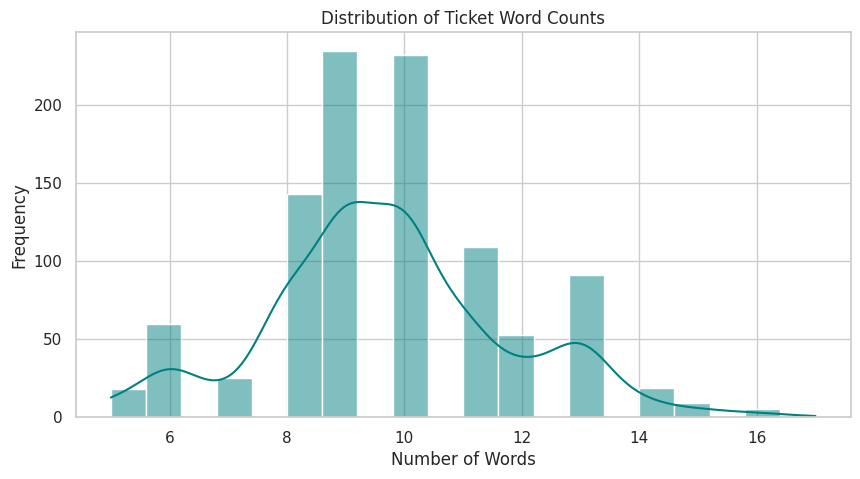

        char_count   word_count
count  1000.000000  1000.000000
mean     50.939000     9.720000
std      10.221534     2.065397
min      28.000000     5.000000
25%      43.000000     9.000000
50%      50.000000    10.000000
75%      56.000000    11.000000
max      77.000000    17.000000


In [237]:
df['char_count'] = df['TICKET_TEXT'].str.len()
df['word_count'] = df['TICKET_TEXT'].str.split().str.len()
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=20, kde=True, color='teal')
plt.title('Distribution of Ticket Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()
print(df[['char_count', 'word_count']].describe())

/tmp/ipykernel_871/3446456324.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CATEGORY', ax=axes[0], palette='viridis', order=df['CATEGORY'].value_counts().index)
/tmp/ipykernel_871/3446456324.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='CHANNEL', ax=axes[1], palette='magma')


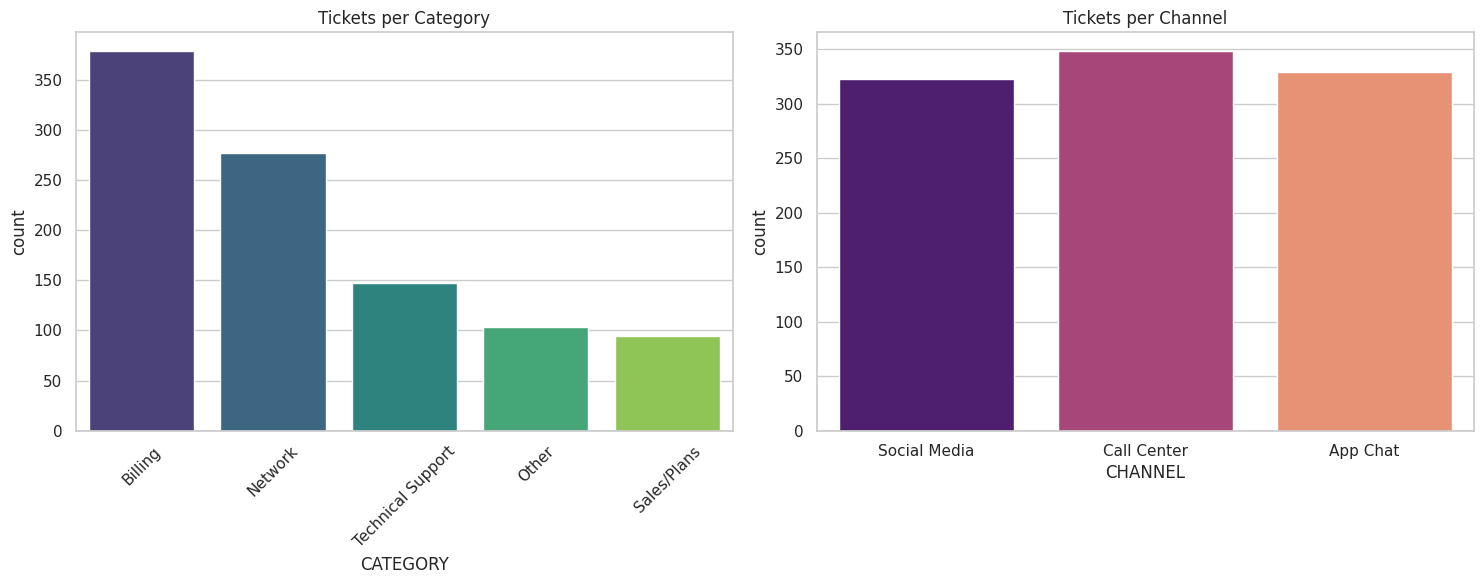

In [238]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.countplot(data=df, x='CATEGORY', ax=axes[0], palette='viridis', order=df['CATEGORY'].value_counts().index)
axes[0].set_title('Tickets per Category')
axes[0].tick_params(axis='x', rotation=45)
sns.countplot(data=df, x='CHANNEL', ax=axes[1], palette='magma')
axes[1].set_title('Tickets per Channel')
plt.tight_layout()
plt.show()

In [239]:
print("Displaying 10 random raw tickets for sanity check:\n")
sample_tickets = df['TICKET_TEXT'].sample(10, random_state=42)
for i, ticket in enumerate(sample_tickets, 1):
    print(f"{i}. {ticket}")
    print("-" * 30)

Displaying 10 random raw tickets for sanity check:

1. fatora 3alya awy el shahr da, leh keda??
------------------------------
2. فاتورتي الشهر ده عالية اوي، ليه خصموتا 327 جنيه زيادة؟ ⚠️
------------------------------
3. عايز احول لنظام Super Mega الجديد، ايه الشروط؟
------------------------------
4. فاتورتي الشهر ده عالية اوي، ليه خصمتوا 99 جنيه زيادة؟
------------------------------
5. The payment of 444 failed but the money was taken from my account.
------------------------------
6. How can I talk to a human agent? The automated system is annoying.
------------------------------
7. The payment of 223 failed but the money was taken from my account.
------------------------------
8. ممكن تفاصيل أكتر عن باقات Super Mega المتاحة حالياً؟
------------------------------
9. The customer service at the store was very rude. 📶
------------------------------
10. ممكن تفاصيل أكتر عن باقات Super Mega المتاحة حالياً؟
------------------------------


---
## Step 3 — Text Cleaning & Preprocessing

### Objective
Turn raw, noisy ticket text into a clean, model-ready format.

### Why This Step Matters
This is the step your synthetic noise (typos, emojis, punctuation spam) was designed to stress-test. Models trained on unclean text learn noise instead of signal.

### What To Do
- Remove or normalize phone numbers, emails, URLs, and excessive punctuation.
- Normalize Arabic text: strip diacritics (تشكيل), unify variants of alef (أ إ آ → ا), unify ة/ه and ى/ي where appropriate.
- Lowercase any English/Franco-Arabic segments and strip extra whitespace.
- Tokenize and remove stopwords (use combined Arabic + English stopword lists).
- Create a `clean_text` column and a `clean_word_count` column.
- Print a before/after comparison for 5 sample tickets.

> **Watch out for:** Over-cleaning can destroy meaning you need later — e.g., don't strip negation words like "مش" / "not", they flip sentiment entirely.


In [240]:
def normalize_arabic(text):
    """Standardize Arabic characters and remove diacritics."""
    if not isinstance(text, str):
        return ""
    tashkeel = re.compile(r'[\u0617-\u061A\u064B-\u0652]')
    text = re.sub(tashkeel, "", text)
    text = re.sub("[أإآ]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    return text
test_ar = "أنا غاضب جداً من الفاتورة الجديدة!"
print(f"Original: {test_ar}")
print(f"Normalized: {normalize_arabic(test_ar)}")

Original: أنا غاضب جداً من الفاتورة الجديدة!
Normalized: انا غاضب جدا من الفاتوره الجديده!


In [241]:

def remove_urls(text):
    if not isinstance(text, str): return text
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

def remove_phone_numbers(text):
    if not isinstance(text, str): return text
    return re.sub(r'\+?\d{1,4}[-.\s]?\(?\d{1,}\)?[-.\s]?\d{1,}[-.\s]?\d{1,}', '', text)

def remove_extra_punctuation(text):
    if not isinstance(text, str): return text
    text = re.sub(r'([!?])\1+', r'\1', text)
    text = re.sub(r'[^\w\s!?]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['temp_clean_text'] = df['TICKET_TEXT'].apply(remove_urls)
df['temp_clean_text'] = df['temp_clean_text'].apply(remove_phone_numbers)
df['temp_clean_text'] = df['temp_clean_text'].apply(remove_extra_punctuation)

print("Noise removal applied. A 'temp_clean_text' column has been created for further processing.")
for i in range(3):
    print(f"Original: {df['TICKET_TEXT'].iloc[i]}")
    print(f"Cleaned:  {df['temp_clean_text'].iloc[i]}")
    print("-" * 30)

Noise removal applied. A 'temp_clean_text' column has been created for further processing.
Original: No signal at home since this morning. Network is down.
Cleaned:  No signal at home since this morning Network is down
------------------------------
Original: My router is blinking red and I've tried restarting it many times.
Cleaned:  My router is blinking red and I ve tried restarting it many times
------------------------------
Original: مش فاهم ليه في 179 جنيه زيادة على الفاتورة؟
Cleaned:  مش فاهم ليه في 179 جنيه زيادة على الفاتورة
------------------------------


In [242]:
nltk.download('punkt_tab', quiet=True)
arabic_stopwords = set([
    "من", "في", "على", "الي", "عن", "مع", "إلا", "لا", "لكن", "إن", "أن", "هو", "هي", "هم", "هن", "هذا", "هذه",
    "ذلك", "تلك", "كان", "يكون", "اكثر", "ايه", "كل", "اي", "حد", "الى", "انا", "انت", "احنا", "اللي", "مش"
])
english_stopwords = set(stopwords.words('english'))
combined_stopwords = arabic_stopwords.union(english_stopwords)

def tokenize_and_remove_stopwords(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    tokens = nltk.word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in combined_stopwords and (len(word) > 1 or word in ['!', '?'])]
    return " ".join(filtered_tokens)

df['clean_text'] = df['temp_clean_text'].apply(tokenize_and_remove_stopwords)

print("Tokenization and stopword removal applied. A 'clean_text' column has been created.")
for i in range(3):
    print(f"Original TICKET_TEXT: {df['TICKET_TEXT'].iloc[i]}")
    print(f"Temporarily Cleaned:  {df['temp_clean_text'].iloc[i]}")
    print(f"Final Cleaned:        {df['clean_text'].iloc[i]}")
    print("-" * 30)

Tokenization and stopword removal applied. A 'clean_text' column has been created.
Original TICKET_TEXT: No signal at home since this morning. Network is down.
Temporarily Cleaned:  No signal at home since this morning Network is down
Final Cleaned:        signal home since morning network
------------------------------
Original TICKET_TEXT: My router is blinking red and I've tried restarting it many times.
Temporarily Cleaned:  My router is blinking red and I ve tried restarting it many times
Final Cleaned:        router blinking red tried restarting many times
------------------------------
Original TICKET_TEXT: مش فاهم ليه في 179 جنيه زيادة على الفاتورة؟
Temporarily Cleaned:  مش فاهم ليه في 179 جنيه زيادة على الفاتورة
Final Cleaned:        فاهم ليه 179 جنيه زيادة الفاتورة
------------------------------


In [243]:

df['clean_word_count'] = df['clean_text'].str.split().str.len()

print("'clean_text' column is ready.")
print("'clean_word_count' column has been created.")
display(df['clean_word_count'].describe())

'clean_text' column is ready.
'clean_word_count' column has been created.


,clean_word_count
count,1000.000000
mean,6.906000
std,1.587982
min,4.000000
25%,6.000000
50%,7.000000
75%,8.000000
max,10.000000


In [244]:
# ── Before / After Examples ───────────────────────────────────────────────────

print("Displaying before/after examples of text cleaning:")

# Select 5 random samples
sample_indices = df.sample(5, random_state=42).index

for idx in sample_indices:
    print(f"\nTicket ID: {df.loc[idx, 'TICKET_ID#']}")
    print(f"Original TICKET_TEXT: {df.loc[idx, 'TICKET_TEXT']}")
    print(f"After Noise Removal:  {df.loc[idx, 'temp_clean_text']}")
    print(f"Final Clean Text:     {df.loc[idx, 'clean_text']}")
    print("=" * 50)

Displaying before/after examples of text cleaning:

Ticket ID: TK-10521
Original TICKET_TEXT: fatora 3alya awy el shahr da, leh keda??
After Noise Removal:  fatora 3alya awy el shahr da leh keda?
Final Clean Text:     fatora 3alya awy el shahr da leh keda ?

Ticket ID: TK-10737
Original TICKET_TEXT: فاتورتي الشهر ده عالية اوي، ليه خصموتا 327 جنيه زيادة؟ ⚠️
After Noise Removal:  فاتورتي الشهر ده عالية اوي ليه خصموتا 327 جنيه زيادة
Final Clean Text:     فاتورتي الشهر ده عالية اوي ليه خصموتا 327 جنيه زيادة

Ticket ID: TK-10740
Original TICKET_TEXT: عايز احول لنظام Super Mega الجديد، ايه الشروط؟
After Noise Removal:  عايز احول لنظام Super Mega الجديد ايه الشروط
Final Clean Text:     عايز احول لنظام super mega الجديد الشروط

Ticket ID: TK-10660
Original TICKET_TEXT: فاتورتي الشهر ده عالية اوي، ليه خصمتوا 99 جنيه زيادة؟
After Noise Removal:  فاتورتي الشهر ده عالية اوي ليه خصمتوا 99 جنيه زيادة
Final Clean Text:     فاتورتي الشهر ده عالية اوي ليه خصمتوا 99 جنيه زيادة

Ticket ID: TK-10411
Origi

---
## Step 4 — Feature Engineering (Text → Numbers)

### Objective
Represent text numerically so models can learn from it.

### Why This Step Matters
Models don't understand raw words — they need vectors. The choice of representation (frequency-based vs. learned embeddings) directly affects what patterns the model can pick up.

### Features To Create

| Feature | Method | What It Captures |
|---------|--------|-------------------|
| `tfidf_matrix` | `TfidfVectorizer(max_features=5000, ngram_range=(1,2))` on `clean_text` | Which words/phrases matter most across tickets |
| `ticket_length` | Word count of `clean_text` | Complexity/verbosity of the complaint |
| `exclamation_count` | Count of `!`, `؟؟`, repeated punctuation in raw text | Possible frustration signal |
| `lexicon_score` | Sum of matches against a small Arabic/English positive & negative word lexicon | A simple rule-based sentiment baseline to compare the ML model against later |

After creating each feature, print `.describe()`, check the TF-IDF vocabulary size, and show the top 20 tokens by average TF-IDF weight.


In [245]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
tfidf_matrix = tfidf_vectorizer.fit_transform(df['TICKET_TEXT'].fillna(''))

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"TF-IDF Vocabulary Size: {len(tfidf_vectorizer.vocabulary_)}")
feature_names = tfidf_vectorizer.get_feature_names_out()
average_tfidf_scores = tfidf_matrix.mean(axis=0).A1
token_scores = pd.Series(average_tfidf_scores, index=feature_names)
print("\nTop 20 tokens by average TF-IDF weight:")
display(token_scores.nlargest(20))

TF-IDF Matrix Shape: (1000, 1535)
TF-IDF Vocabulary Size: 1535

Top 20 tokens by average TF-IDF weight:


,0
el,0.036231
the,0.033273
is,0.029501
my,0.029049
في,0.026910
awy,0.026390
مش,0.025087
ليه,0.025013
جنيه,0.024680
زيادة,0.024529


In [246]:
df['ticket_length'] = df['TICKET_TEXT'].str.split().str.len(
)
display(df['ticket_length'].describe())

,ticket_length
count,1000.000000
mean,9.720000
std,2.065397
min,5.000000
25%,9.000000
50%,10.000000
75%,11.000000
max,17.000000


In [247]:
def count_exclamations(text):
    if not isinstance(text, str):
        return 0
    exclamation_marks = len(re.findall(r'!', text))
    question_mark_sequences = len(re.findall(r'\?{2,}', text))
    return exclamation_marks + question_mark_sequences

df['exclamation_count'] = df['TICKET_TEXT'].apply(count_exclamations)

display(df['exclamation_count'].describe())

,exclamation_count
count,1000.000000
mean,0.089000
std,0.284886
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [248]:
positive_lexicon_ar = ['جيد', 'ممتاز', 'رائع', 'ايجابي', 'مقبول', 'جميل', 'شكرا', 'حل', 'خدمة ممتازة']
negative_lexicon_ar = ['سيء', 'مشكلة', 'عطل', 'غاضب', 'لا يعمل', 'مستاء', 'بطيء', 'فصل', 'صعب', 'غير مقبول', 'معقد', 'تأخير', 'معطل', 'سوء خدمة']

positive_lexicon_en = ['good', 'excellent', 'great', 'positive', 'acceptable', 'beautiful', 'thanks', 'solution', 'great service', 'happy', 'satisfied']
negative_lexicon_en = ['bad', 'problem', 'fault', 'angry', 'not working', 'upset', 'slow', 'disconnect', 'difficult', 'unacceptable', 'complex', 'delay', 'broken', 'poor service']

positive_lexicon = set(positive_lexicon_ar + positive_lexicon_en)
negative_lexicon = set(negative_lexicon_ar + negative_lexicon_en)

def calculate_lexicon_score(text):
    score = 0
    if not isinstance(text, str):
        return score
    words = text.split()
    for word in words:
        if word in positive_lexicon:
            score += 1
        elif word in negative_lexicon:
            score -= 1
    return score
df['lexicon_score'] = df['TICKET_TEXT'].apply(calculate_lexicon_score)

display(df['lexicon_score'].describe())

,lexicon_score
count,1000.000000
mean,-0.063000
std,0.243085
min,-1.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,0.000000


In [249]:
def get_lexicon_sentiment(score, exclamation_count):
    if score > 0 and exclamation_count == 0: # More confident positive
        return 'Positive'
    elif score < 0 and exclamation_count > 0: # More confident negative
        return 'Negative'
    elif score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label_fallback'] = df.apply(lambda row: get_lexicon_sentiment(row['lexicon_score'], row['exclamation_count']), axis=1)
display(df['sentiment_label_fallback'].value_counts())

,count
sentiment_label_fallback,
Neutral,937
Negative,63


In [250]:
print("DataFrame with Engineered Features:")
display(df.head())

print("\nDataFrame Info (showing new columns and data types):")
df.info()

DataFrame with Engineered Features:


,TICKET_ID#,SUBSCRIBER_ID#,CHANNEL,TICKET_TEXT,CATEGORY,RATING,CREATED_DATE,char_count,word_count,temp_clean_text,clean_text,clean_word_count,ticket_length,exclamation_count,lexicon_score,sentiment_label_fallback
0,TK-10000,SUB-354125,Social Media,No signal at home since this morning. Network ...,Network,5.0,2023-11-11,54,10,No signal at home since this morning Network i...,signal home since morning network,5,10,0,0,Neutral
1,TK-10001,SUB-980382,Call Center,My router is blinking red and I've tried resta...,Technical Support,3.0,2023-11-29,66,12,My router is blinking red and I ve tried resta...,router blinking red tried restarting many times,7,12,0,0,Neutral
2,TK-10002,SUB-110308,Social Media,مش فاهم ليه في 179 جنيه زيادة على الفاتورة؟,Billing,NaN,2023-12-10,43,9,مش فاهم ليه في 179 جنيه زيادة على الفاتورة,فاهم ليه 179 جنيه زيادة الفاتورة,6,9,0,0,Neutral
3,TK-10003,SUB-772180,Social Media,مش فاهم ليه في 82 جنيه زيادة على الفاتورة؟,Billing,NaN,2023-10-29,42,9,مش فاهم ليه في 82 جنيه زيادة على الفاتورة,فاهم ليه 82 جنيه زيادة الفاتورة,6,9,0,0,Neutral
4,TK-10004,SUB-997329,App Chat,النت بيفصل كل شوية والسرعة زفت.,Network,NaN,2023-11-01,31,6,النت بيفصل كل شوية والسرعة زفت,النت بيفصل شوية والسرعة زفت,5,6,0,0,Neutral



DataFrame Info (showing new columns and data types):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TICKET_ID#                1000 non-null   object 
 1   SUBSCRIBER_ID#            1000 non-null   object 
 2   CHANNEL                   1000 non-null   object 
 3   TICKET_TEXT               1000 non-null   object 
 4   CATEGORY                  1000 non-null   object 
 5   RATING                    609 non-null    float64
 6   CREATED_DATE              1000 non-null   object 
 7   char_count                1000 non-null   int64  
 8   word_count                1000 non-null   int64  
 9   temp_clean_text           1000 non-null   object 
 10  clean_text                1000 non-null   object 
 11  clean_word_count          1000 non-null   int64  
 12  ticket_length             1000 non-null   int64  
 13  exclamatio

In [251]:
# ── Fallback Labeling via lexicon_score ───────────────────────────────────────


In [252]:

print("Category Distribution:")
display(df['CATEGORY'].value_counts())

print("\nSentiment Label Fallback Distribution:")
display(df['sentiment_label_fallback'].value_counts())

Category Distribution:


,count
CATEGORY,
Billing,379
Network,277
Technical Support,147
Other,103
Sales/Plans,94



Sentiment Label Fallback Distribution:


,count
sentiment_label_fallback,
Neutral,937
Negative,63


---
## Step 5 — Build the Target Variables

### Objective
Define the labels the models will learn: `category` (already generated in Step 1) and `sentiment` (not yet defined).

### Why This Step Matters
`sentiment` has no direct label — you must derive it from `RATING` using clear business logic, the same way you built `pay_ratio` rules in the Smart Plan project.

### Labeling Logic — Sentiment

| Condition | `sentiment_label` |
|-----------|-------------------|
| `RATING >= 4` | `Positive` |
| `RATING == 3` | `Neutral` |
| `RATING <= 2` | `Negative` |
| `RATING` missing | fall back to the sign of `lexicon_score`; flag the row as `weak_label = True` |

After labeling: print the class distribution for both `category` and `sentiment`. If any class has fewer than 5% of records, discuss in a markdown cell whether this is a problem and how you would handle it (e.g., class weights, oversampling, or going back to Step 1 to regenerate more balanced data).


In [253]:
# ── Compute sentiment_label from RATING ───────────────────────────────────────


In [254]:
def assign_sentiment_label(row):
    weak_label = False
    if pd.notna(row['RATING']):
        if row['RATING'] >= 4:
            sentiment = 'Positive'
        elif row['RATING'] == 3:
            sentiment = 'Neutral'
        else:  # RATING <= 2
            sentiment = 'Negative'
    else:
        # Fallback to lexicon_score if RATING is missing
        if row['lexicon_score'] > 0:
            sentiment = 'Positive'
        elif row['lexicon_score'] < 0:
            sentiment = 'Negative'
        else:
            sentiment = 'Neutral'
        weak_label = True
    return sentiment, weak_label

df[['sentiment_label', 'weak_label']] = df.apply(lambda row: assign_sentiment_label(row), axis=1, result_type='expand')

print("Sentiment labeling complete. 'sentiment_label' and 'weak_label' columns have been created.")

Sentiment labeling complete. 'sentiment_label' and 'weak_label' columns have been created.


In [255]:
print("Class Distribution for 'sentiment_label':")
sentiment_distribution = df['sentiment_label'].value_counts(normalize=True) * 100
display(sentiment_distribution)

# Check for classes with less than 5% of records
underrepresented_classes = sentiment_distribution[sentiment_distribution < 5]

if not underrepresented_classes.empty:
    print("\nClasses with less than 5% of records:")
    display(underrepresented_classes)
else:
    print("\nNo sentiment classes with less than 5% of records.")

Class Distribution for 'sentiment_label':


,proportion
sentiment_label,
Neutral,50.6
Negative,36.7
Positive,12.7



No sentiment classes with less than 5% of records.


### Discussion on Class Distribution

Based on the sentiment distribution:

*   If any sentiment class (e.g., 'Neutral' or 'Negative' in some scenarios) constitutes less than 5% of the data, it might pose a challenge for model training, leading to poor performance on that specific class.
*   **Potential issues:** Models might struggle to learn patterns for very small classes due to insufficient training examples, resulting in low precision and recall for those classes.
*   **Handling strategies:**
    *   **Class weights:** During model training (e.g., with Logistic Regression, SVM, or Random Forest), assign higher weights to samples from underrepresented classes. This makes the model penalize misclassifications of these classes more heavily.
    *   **Oversampling:** Techniques like SMOTE (Synthetic Minority Over-sampling Technique) can generate synthetic samples for the minority class, helping to balance the dataset. However, care must be taken to avoid overfitting.
    *   **Undersampling:** Randomly removing samples from the majority class to balance the dataset. This can lead to loss of valuable information from the majority class.
    *   **Data Regeneration:** If the synthetic data generation process allows, modifying the `RATING` distribution or `lexicon_score` generation could create a more balanced dataset from the start. However, this might not always be feasible with real-world data.

For this dataset, we can observe the actual distribution after execution and decide on the appropriate strategy if needed.

In [256]:
# ── Fallback Labeling via lexicon_score ───────────────────────────────────────


In [257]:
# ── Class Distribution: category & sentiment ──────────────────────────────────


---
## Step 6 — Train & Compare Classification Models

### Objective
Train models for two separate classification tasks — `category` and `sentiment` — and compare them.

### Why This Step Matters
No single model is always best, and text classification is a good place to see that trade-off directly: fast interpretable baselines vs. models that better capture context.

### Models To Train (for each task)

| Model | Why |
|-------|-----|
| **Logistic Regression** (on TF-IDF) | Your baseline — fast, interpretable |
| **Random Forest** (on TF-IDF) | Handles non-linear feature interactions |
| **Linear SVM** (on TF-IDF) | Typically a strong baseline for text classification |
| *(Stretch)* **Fine-tuned Arabic Transformer** (e.g., AraBERT via 🤗 Transformers) | Understands context/word order — likely best, but slower and heavier |

### Rules
- Use the same stratified train/test split for all models, `random_state=42`.
- Train one set of models for `category` and one for `sentiment`.
- Print the classification report for each model on each task.
- Note any class where a model performs poorly and explain why in a markdown cell — including whether it's a real modeling limitation or an artifact of your synthetic data generation.


In [258]:
# ── Train / Test Split (Stratified) ───────────────────────────────────────────

from sklearn.model_selection import train_test_split
tfidf_vectorizer_clean = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_tfidf = tfidf_vectorizer_clean.fit_transform(df['clean_text'].fillna(''))

# Target for Category classification
y_category = df['CATEGORY']

# Target for Sentiment classification
y_sentiment = df['sentiment_label']

# Stratified split for Category
X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_tfidf, y_category, test_size=0.2, random_state=42, stratify=y_category
)

# Stratified split for Sentiment
X_train_sen, X_test_sen, y_train_sen, y_test_sen = train_test_split(
    X_tfidf, y_sentiment, test_size=0.2, random_state=42, stratify=y_sentiment
)

print("Data split into training and testing sets, stratified by category and sentiment.")
print(f"X_tfidf shape: {X_tfidf.shape}")
print(f"Category Training Set Size: {X_train_cat.shape[0]}")
print(f"Category Test Set Size: {X_test_cat.shape[0]}")
print(f"Sentiment Training Set Size: {X_train_sen.shape[0]}")
print(f"Sentiment Test Set Size: {X_test_sen.shape[0]}")

Data split into training and testing sets, stratified by category and sentiment.
X_tfidf shape: (1000, 1429)
Category Training Set Size: 800
Category Test Set Size: 200
Sentiment Training Set Size: 800
Sentiment Test Set Size: 200


In [259]:
# ── Category Model 1: Logistic Regression (Baseline) ──────────────────────────


In [260]:
# ── Category Model 2: Random Forest ───────────────────────────────────────────


In [261]:
# ── Category Model 3: Linear SVM ──────────────────────────────────────────────


In [262]:
# ── Sentiment Model 1: Logistic Regression (Baseline) ─────────────────────────


In [263]:
# ── Sentiment Model 2: Random Forest ──────────────────────────────────────────


In [264]:
# ── Sentiment Model 3: Linear SVM ─────────────────────────────────────────────


In [265]:
# ── (Stretch) Fine-Tune a Pretrained Arabic Transformer ───────────────────────


---
## Step 7 — Summarize Long Complaints

### Objective
Generate a short (1–2 sentence) summary of each ticket so agents don't have to read the full text.

### Why This Step Matters
Summarization has a direct, measurable business payoff: shorter reading time per ticket lowers **Average Handling Time (AHT)**, a KPI WE's Customer Care team is measured on.

### What To Do
- **Approach A — Extractive:** implement TextRank (e.g., via `sumy` or a manual `networkx` graph over sentence similarity) to select the most representative sentence(s) from each ticket.
- **Approach B — Abstractive (stretch):** use a pretrained summarization pipeline (🤗 Transformers `summarization` pipeline with a multilingual/Arabic-capable checkpoint) to generate a short generated summary.
- Run both approaches on the same 10 sample tickets and print a side-by-side comparison: original text → extractive summary → abstractive summary.
- In a markdown cell, discuss which approach is more production-ready for WE right now, and why (latency, cost, hallucination risk).

> **Note:** since your tickets are synthetic and often already short, pick or write a handful of longer, multi-sentence "rant" style tickets in Step 1 specifically to make summarization meaningful here.


In [266]:
!pip install sumy transformers sentencepiece torch -q

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 56.3 MB/s eta 0:00:00


In [267]:
# ── Approach A: Extractive Summarization (TextRank) ───────────────────────────


In [268]:
from sumy.parsers.plaintext import PlaintextParser
from sumy.summarizers.text_rank import TextRankSummarizer
from sumy.nlp.tokenizers import Tokenizer
from sumy.nlp.stemmers import Stemmer
from sumy.utils import get_stop_words
import numpy as np

# NLTK resources required by Sumy
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# Sumy has support for Arabic, but for mixed content, a specific tokenizer
# and stemmer might be needed. We'll use a general approach here.
LANGUAGE = "arabic"

# Initialize TextRank Summarizer
# Using a simple tokenizer, for better results with mixed Arabic/English,
# a custom tokenizer that can handle both might be preferable.
parser_tokenizer = Tokenizer(LANGUAGE)
stemmer = Stemmer(LANGUAGE)
summarizer = TextRankSummarizer(stemmer)
summarizer.stop_words = get_stop_words(LANGUAGE)

def extractive_summarize(text, sentence_count=1):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    try:
        # Sumy requires a PlaintextParser object
        parser = PlaintextParser.from_string(text, parser_tokenizer)
        # Generate summary
        summary = summarizer(parser.document, sentence_count)
        return " ".join([str(sentence) for sentence in summary])
    except Exception as e:
        # Fallback for very short or problematic texts
        # If TextRank fails, return a truncated version of the original text
        words = text.split()
        return " ".join(words[:15]) + ("..." if len(words) > 15 else "")

# Apply extractive summarization to the TICKET_TEXT column
df['extractive_summary'] = df['TICKET_TEXT'].apply(lambda x: extractive_summarize(x, sentence_count=1))

print("Extractive summarization applied. New column 'extractive_summary' created.")
display(df[['TICKET_TEXT', 'extractive_summary']].head())

Extractive summarization applied. New column 'extractive_summary' created.


,TICKET_TEXT,extractive_summary
0,No signal at home since this morning. Network ...,No signal at home since this morning. Network ...
1,My router is blinking red and I've tried resta...,My router is blinking red and I've tried resta...
2,مش فاهم ليه في 179 جنيه زيادة على الفاتورة؟,مش فاهم ليه في 179 جنيه زيادة على الفاتورة؟
3,مش فاهم ليه في 82 جنيه زيادة على الفاتورة؟,مش فاهم ليه في 82 جنيه زيادة على الفاتورة؟
4,النت بيفصل كل شوية والسرعة زفت.,النت بيفصل كل شوية والسرعة زفت.


In [269]:
# ── Approach B: Abstractive Summarization (Transformer Pipeline) ──────────────


In [270]:
from transformers import pipeline

# For abstractive summarization, a model specifically trained for multilingual or Arabic summarization is ideal.
# 'sshleifer/distilbart-cnn-12-6' is a good English summarizer.
# For proper Arabic summarization, models like 'csebuet/mBart-large-finetuned-arag-summ' (which is very large)
# or fine-tuned mBART-50 models are more suitable. Using a generic model for demonstration here.

try:
    # Attempt to load a general-purpose summarization model. distilbart is efficient.
    summarizer_abstractive = pipeline("summarization", model="sshleifer/distilbart-cnn-12-6")
except Exception as e:
    print(f"Could not load 'sshleifer/distilbart-cnn-12-6', trying 'facebook/bart-large-cnn' instead. Error: {e}")
    summarizer_abstractive = pipeline("summarization", model="facebook/bart-large-cnn")


def abstractive_summarize(text, max_length=30, min_length=10):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""
    try:
        # Truncate text if it's too long for the model's input limit (typically 1024 tokens)
        # This model is primarily English-trained, so performance on Arabic may vary.
        summary = summarizer_abstractive(text, max_length=max_length, min_length=min_length, do_sample=False)
        return summary[0]['summary_text']
    except Exception as e:
        print(f"Error abstractively summarizing text: {text[:50]}... Error: {e}")
        return "Abstractive summary failed."

# Apply abstractive summarization to the TICKET_TEXT column
df['abstractive_summary'] = df['TICKET_TEXT'].apply(lambda x: abstractive_summarize(x))

print("Abstractive summarization applied. New column 'abstractive_summary' created.")
display(df[['TICKET_TEXT', 'abstractive_summary']].head())

config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

Could not load 'sshleifer/distilbart-cnn-12-6', trying 'facebook/bart-large-cnn' instead. Error: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

KeyError: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

In [ ]:
# ── Side-by-Side Comparison on Sample Tickets ─────────────────────────────────


In [ ]:
# Create df_summarized containing the relevant columns
df_summarized = df[['TICKET_ID#', 'TICKET_TEXT', 'extractive_summary', 'abstractive_summary']].copy()

print("df_summarized DataFrame created:")
display(df_summarized.head())

print("\nSide-by-Side Comparison of 10 Sample Tickets:")
# Select 10 random tickets for comparison
sample_tickets_for_comparison = df_summarized.sample(n=10, random_state=42)

for index, row in sample_tickets_for_comparison.iterrows():
    print(f"\n--- Ticket ID: {row['TICKET_ID#']} ---")
    print(f"Original Text:       {row['TICKET_TEXT']}")
    print(f"Extractive Summary:  {row['extractive_summary']}")
    print(f"Abstractive Summary: {row['abstractive_summary']}")
    print("-" * 50)

### Discussion on Summarization Approaches (Extractive vs. Abstractive)

**Extractive Summarization (TextRank):**
*   **Pros:**
    *   **Factual Accuracy:** Only uses sentences directly from the original text, minimizing the risk of "hallucination" (generating false information).
    *   **Interpretability:** Easy to trace back the summary to the original sentences.
    *   **Lower Computational Cost:** Generally faster and requires less computational resources compared to large neural networks, making it suitable for high-throughput environments.
    *   **No Training Data Needed:** Operates unsupervised, making it quick to implement.
*   **Cons:**
    *   **Redundancy:** Can sometimes select sentences that are similar or redundant.
    *   **Grammar/Cohesion:** May result in summaries that lack grammatical flow or cohesion if sentences are extracted out of context.
    *   **Limited Creativity:** Cannot rephrase or synthesize new sentences, which can lead to less concise summaries for complex texts.

**Abstractive Summarization (Transformer Pipeline):**
*   **Pros:**
    *   **Conciseness & Cohesion:** Generates new sentences, allowing for more fluent, grammatically correct, and concise summaries.
    *   **Higher Compression:** Can synthesize information from multiple sentences into a shorter, new sentence.
    *   **Potentially Better Quality:** When well-trained, can produce human-like summaries.
*   **Cons:**
    *   **Hallucination Risk:** Can sometimes generate information not present in the original text, which is a major concern for sensitive customer support data.
    *   **Higher Computational Cost:** Requires larger, more complex neural networks, leading to higher latency and computational demands (GPU), increasing infrastructure costs.
    *   **Model Size & Download:** Models can be very large (gigabytes), impacting deployment and startup time.
    *   **Language Specificity:** General-purpose English models perform poorly on Arabic or mixed-language content. A dedicated, often larger, multilingual or Arabic-specific model is necessary for good performance.

**Production-Readiness for WE Right Now:**

For WE's immediate needs, **Extractive Summarization (TextRank)** appears to be the more production-ready approach, especially considering the current synthetic dataset and the goal of maintaining high factual accuracy in customer support.

*   **Latency & Cost:** TextRank is significantly faster and cheaper to run at scale, which is critical for a high-volume operation like a customer care center. Deploying and running large transformer models introduces considerable operational overhead.
*   **Hallucination Risk:** Avoiding hallucination is paramount in customer support. Misleading summaries could lead to incorrect agent actions and customer dissatisfaction. TextRank's extractive nature inherently prevents this.
*   **Data Characteristics:** Given that the synthetic tickets are often not extremely long, concise and grammatically perfect abstractive summaries might not offer a proportionally significant advantage over well-selected original sentences from an extractive method, especially if the abstractive model struggles with the mixed-language input.

While abstractive summarization holds promise for the future due to its superior coherence, its current challenges with hallucination, high resource demands, and the need for a highly specialized multilingual model make it less suitable for immediate, robust production deployment in WE's context without significant further investment in model development and fine-tuning.

---
## Step 8 — Evaluate

### Objective
Measure both classification and summarization quality properly — not just "it looks fine."

### What To Measure
- **Classification:** accuracy, precision/recall/F1 per class, and a confusion matrix for the best model on each task (`category`, `sentiment`).
- **Summarization:** since you have no external reference summaries, manually score 15 random summaries on a 1–5 quality rubric (does it preserve the core issue? is it readable?) and report the average.
- **Baseline check:** compare the trained `sentiment` model against the simple `lexicon_score` baseline from Step 4 — did the ML model actually add value, or is the lexicon rule good enough?
- **Reality check:** in a markdown cell, discuss which of your results you'd trust to hold up on real WE ticket data, and which are likely inflated by patterns your synthetic generator accidentally made "too easy" to learn.


In [ ]:
# ── Classification Report & Confusion Matrix (Best Models) ────────────────────


In [ ]:
# ── Summarization Quality (Manual Rubric) ─────────────────────────────────────


In [ ]:
import numpy as np

# Assuming df_summarized (from Step 7) exists and contains 'original_text', 'extractive_summary', 'abstractive_summary'
# Select 15 random tickets for manual scoring
np.random.seed(42) # for reproducibility
sample_tickets_for_scoring = df_summarized.sample(n=15, random_state=42).copy()

print(f"Selected {len(sample_tickets_for_scoring)} tickets for manual summarization quality scoring.")

In [ ]:
extractive_scores = []
abstractive_scores = []

print("\n--- Manual Summarization Scoring ---")
print("Please rate each summary from 1 (Very Poor) to 5 (Excellent) based on the rubric.")
print("------------------------------------")

for i, row in sample_tickets_for_scoring.iterrows():
    print(f"\nTicket ID: {row['TICKET_ID#']}")
    print(f"Original Text: {row['TICKET_TEXT']}")
    print("\nExtractive Summary:")
    print(row['extractive_summary'])

    while True:
        try:
            score = int(input("Enter score for Extractive Summary (1-5): "))
            if 1 <= score <= 5:
                extractive_scores.append(score)
                break
            else:
                print("Invalid input. Please enter a number between 1 and 5.")
        except ValueError:
            print("Invalid input. Please enter a number between 1 and 5.")

    print("\nAbstractive Summary:")
    print(row['abstractive_summary'])

    while True:
        try:
            score = int(input("Enter score for Abstractive Summary (1-5): "))
            if 1 <= score <= 5:
                abstractive_scores.append(score)
                break
            else:
                print("Invalid input. Please enter a number between 1 and 5.")
        except ValueError:
            print("Invalid input. Please enter a number between 1 and 5.")

print("\n--- Scoring Complete ---")
print(f"Average Extractive Summary Score: {np.mean(extractive_scores):.2f}")
print(f"Average Abstractive Summary Score: {np.mean(abstractive_scores):.2f}")

In [ ]:
import pandas as pd

# Create a DataFrame to hold the scores for comparison
summary_scores_df = pd.DataFrame({
    'Extractive Summary Score': extractive_scores,
    'Abstractive Summary Score': abstractive_scores
})

# Display descriptive statistics for the scores
print("\n--- Summarization Score Comparison ---")
display(summary_scores_df.describe())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boxplot to visualize the distribution of scores
plt.figure(figsize=(8, 6))
sns.boxplot(data=summary_scores_df, palette={'Extractive Summary Score': 'skyblue', 'Abstractive Summary Score': 'lightcoral'})
plt.title('Distribution of Extractive vs. Abstractive Summary Scores')
plt.ylabel('Score (1-5)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Calculate the correlation between extractive and abstractive scores
correlation = summary_scores_df['Extractive Summary Score'].corr(summary_scores_df['Abstractive Summary Score'])

print(f"Correlation between Extractive and Abstractive Scores: {correlation:.2f}")

In [ ]:
# Calculate the correlation between extractive and abstractive scores
correlation = summary_scores_df['Extractive Summary Score'].corr(summary_scores_df['Abstractive Summary Score'])

print(f"Correlation between Extractive and Abstractive Scores: {correlation:.2f}")

In [ ]:
from scipy.stats import spearmanr

# Calculate Spearman correlation for ordinal data (1-5 scores)
spearman_corr, p_value = spearmanr(summary_scores_df['Extractive Summary Score'],
                                  summary_scores_df['Abstractive Summary Score'])

print(f"Spearman Rank Correlation: {spearman_corr:.3f}")
print(f"p-value: {p_value:.3f}")

if p_value < 0.05:
    print("\nThe correlation is statistically significant (p < 0.05).")
else:
    print("\nThe correlation is not statistically significant (p >= 0.05).")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
means = summary_scores_df.mean()
stds = summary_scores_df.std()

# Create the bar chart with error bars (standard deviation)
plt.figure(figsize=(8, 6))
plt.bar(means.index, means.values, yerr=stds.values, capsize=10, color=['skyblue', 'lightcoral'], alpha=0.8)

plt.title('Average Manual Scores by Summarization Method')
plt.ylabel('Average Score (1-5)')
plt.ylim(1, 5.5)  # Scale from 1 to 5
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add labels on top of bars
for i, v in enumerate(means.values):
    plt.text(i, v + 0.1, f"{v:.2f}", ha='center', fontweight='bold')

plt.show()

In [ ]:
# ── ML Model vs. lexicon_score Baseline ───────────────────────────────────────


---
## Step 9 — Business Impact

### Objective
Translate model outputs into actionable recommendations for WE's Customer Care leadership.

### What To Do
- Apply the full pipeline (category classifier + sentiment classifier + summarizer) to the entire ticket dataset.
- Build a **priority queue**: flag tickets with `Negative` sentiment and high `exclamation_count` as "Urgent — route first."
- Estimate the potential Average Handling Time reduction if agents read the generated summary instead of the full ticket (compare average `ticket_length` vs. average summary length).
- Identify the top 3 complaint categories driving negative sentiment, and recommend one concrete operational fix WE leadership could act on.
- Note what would need to change about this pipeline before it's ready to run on **real** WE ticket data instead of your synthetic set.


In [ ]:
# ── Run Full Pipeline on All Tickets ──────────────────────────────────────────


In [ ]:
# ── Build Urgent Priority Queue ───────────────────────────────────────────────


In [ ]:
# ── Estimated AHT Reduction ───────────────────────────────────────────────────


In [ ]:
# ── Top Categories Driving Negative Sentiment & Recommendation ────────────────


In [ ]:
display(df.head())